In [106]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt 

import portfolio
import market_data
import models
import simulation
import risk_measure

# import arch

import importlib

my_modules = [portfolio, market_data, models, simulation, risk_measure]

for module in  my_modules:
    importlib.reload(module)


[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

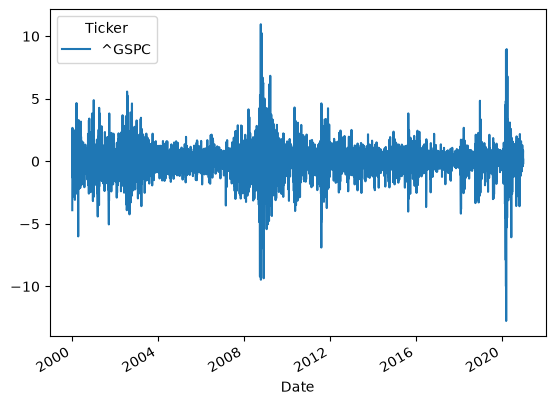

In [107]:
port = portfolio.Portfolio(
    holdings={
        "^GSPC": 1,
    }
)

data = market_data.MarketData.from_yfinance(
    port.assets,
    "2000-01-01",
    "2020-12-31",
)

risk_factors = port.risk_factors(data)
risk_factors.plot()

Date
2000-01-04         NaN
2000-01-05         NaN
2000-01-06         NaN
2000-01-07         NaN
2000-01-10         NaN
                ...   
2020-12-23    0.876863
2020-12-24    0.842011
2020-12-28    0.813316
2020-12-29    0.810953
2020-12-30    0.780504
Name: ^GSPC, Length: 5282, dtype: float64


<Axes: xlabel='Date'>

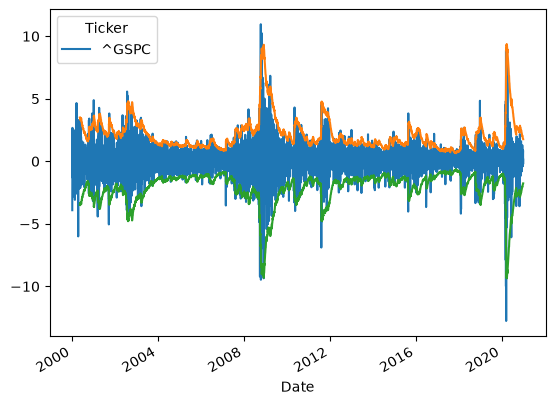

In [108]:
ewma = models.univariate_ewma_variance_estimator(
    risk_factors
)

print(ewma.variances)
risk_factors.plot()
(2*np.sqrt(ewma.variances)).plot()
(-2*np.sqrt(ewma.variances)).plot()

In [109]:
garch1_1 = models.fit_garch(risk_factors)
print("GARCH(1,1) model:", "\n", garch1_1.summary(), "\n")

GARCH(1,1) model: 
                        Zero Mean - GARCH Model Results                        
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -7291.28
Distribution:                  Normal   AIC:                           14588.6
Method:            Maximum Likelihood   BIC:                           14608.3
                                        No. Observations:                 5282
Date:                Thu, Sep 17 2026   Df Residuals:                     5282
Time:                        12:20:34   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0225  4.966e-03      

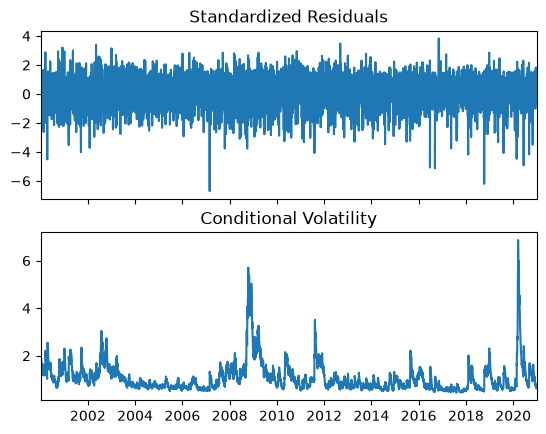

In [110]:
garch1_1.plot()
plt.show()
plt.close()

<Axes: xlabel='Date'>

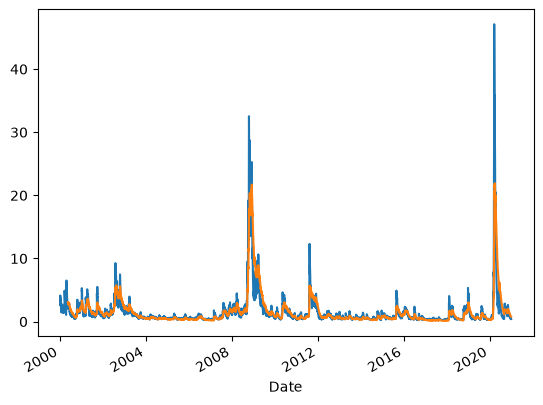

In [111]:
garch1_1_cond_var = (models.garch_conditional_variance(garch1_1).variances)
garch1_1_cond_var.plot()
(ewma.variances).plot()

In [112]:
models.garch_forecast(garch1_1)

,h.1
Date,
2020-12-30,0.389315


0.01   -2.326348
0.05   -1.644854
Name: quantile, dtype: float64
                  1%        5%
Date                          
2000-01-04  3.769202  2.665029
2000-01-05  4.731271  3.345264
2000-01-06  4.411591  3.119233
2000-01-07  4.113614  2.908548
2000-01-10  4.404465  3.114195
...              ...       ...
2020-12-23  1.572282  1.111688
2020-12-24  1.502783  1.062549
2020-12-28  1.466922  1.037193
2020-12-29  1.572250  1.111666
2020-12-30  1.512340  1.069306

[5282 rows x 2 columns]


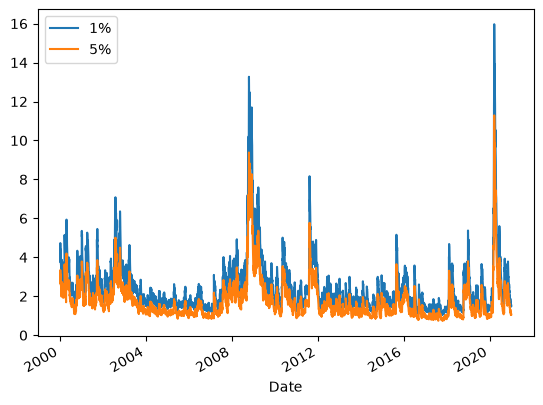

In [117]:
q = simulation.parametric_quantiles(garch1_1,[0.01,0.05])
print(q)

VaR = risk_measure.parametric_value_at_risk(garch1_1_cond_var,q)
print(VaR)
# risk_factors.plot()
VaR.plot()
plt.show()

                  1%        5%
Date                          
2000-01-04  4.318241  3.342054
2000-01-05  5.420449  4.195096
2000-01-06  5.054203  3.911644
2000-01-07  4.712822  3.647436
2000-01-10  5.046039  3.905326
...              ...       ...
2020-12-23  1.801307  1.394102
2020-12-24  1.721685  1.332479
2020-12-28  1.680601  1.300682
2020-12-29  1.801272  1.394074
2020-12-30  1.732635  1.340953

[5282 rows x 2 columns]


<Axes: xlabel='Date'>

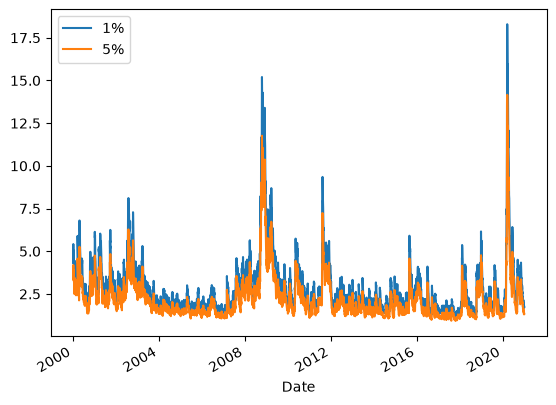

In [121]:
tail_means=simulation.parametric_tail_means(garch1_1,[0.01,0.05])
Es=risk_measure.expected_shortfall(garch1_1_cond_var,tail_means)
print(Es)
Es.plot()
